# 16. Scaling du test-time compute (Snell 2024)

**Phase 4 de l'epic #2926** — suite de **NB-12** (moteurs), **NB-13** (routeur), **NB-14**
(memoire), **NB-15** (ToT sur CSP).

## L'idee de Snell et al. 2024

> *"Scaling LLM Test-Time Compute Optimally can be more effective than scaling model
> parameters."* — Snell, Lee, Xu, Kumar (DeepMind, 2024).

Le **test-time compute** (combien de calcul on depense a l'inference : plus d'echantillons,
plus de recherche, plus de tours de Reflexion) se met a l'echelle **comme le compute
d'entrainement**. Mais la strategie **optimale** depend du **regime** :

- Sur des problemes **faciles (pour le modele)** : **echantillonner large en parallele**
  (Best-of-N) est le plus efficace — un seul essai rate rarement.
- Sur des problemes **difficiles** : la **recherche sequentielle** (affiner via le retour
  d'un verificateur, facon Reflexion) est plus compute-efficace qu'echantillonner a l'aveugle.

Il existe donc une **frontiere compute-optimale** : pour un budget donne, quelle strategie
maximise le taux de succes depend de la difficulte.

## Plan (ce notebook mesure tout sur de vraies donnees)
1. **Suite graduee** de problemes a **reponse entiere verifiable** (facile / moyen / difficile).
2. **Scaling BoN** : pass@k (estimateur non-biasé HumanEval) pour k = 1, 2, 4, 6, par bucket.
3. **Compute-optimal** : a budget egal, **BoN (parallele)** vs **Reflexion (sequentiel)**.
4. **Limites honnetes** (G.2) : petit N, petit modele, bruit — les lois de Snell sont
   asymptotiques ; ce notebook est **illustratif**, pas une replication a l'echelle.

> Pont Phase 5 : comparer a un **modele a raisonnement natif** (le raisonnement est alors
> "interne" au modele, compute decale dans les tokens de pensée).

## 0. Setup — meme infrastructure que NB-12 a NB-15

In [1]:
%pip install -q openai python-dotenv matplotlib numpy

import os, re, math, time
from pathlib import Path
from functools import lru_cache
from openai import OpenAI
from dotenv import load_dotenv

_env_path = None
_current = Path.cwd()
for _i in range(10):
    if (_current / ".env").exists():
        _env_path = _current / ".env"; break
    if _current.name in ("GenAI", "MyIA.AI.Notebooks"):
        break
    _current = _current.parent
if _env_path is None:
    for _cand in (Path.cwd() / "MyIA.AI.Notebooks" / "GenAI" / ".env",
                  Path.cwd() / "GenAI" / ".env"):
        if _cand.exists():
            _env_path = _cand; break
if _env_path is not None:
    load_dotenv(_env_path); print(f".env charge depuis : {_env_path}")

FAST_MODEL = os.getenv("OPENAI_MODEL_FAST", "meta-llama/llama-3.3-70b-instruct")
BIG_MODEL = os.getenv("OPENAI_MODEL_BIG", "openai/gpt-5-nano")
BATCH_MODE = os.getenv("BATCH_MODE", "true").lower() in ("1", "true", "yes")
client = OpenAI(api_key=os.getenv("OPENROUTER_API_KEY"),
                base_url=os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1"))
print(f"FAST_MODEL={FAST_MODEL} | BATCH_MODE={BATCH_MODE}")

Note: you may need to restart the kernel to use updated packages.


.env charge depuis : D:\dev\CoursIA\MyIA.AI.Notebooks\GenAI\.env


FAST_MODEL=meta-llama/llama-3.3-70b-instruct | BATCH_MODE=False


In [2]:
def chat(prompt, system=None, model=FAST_MODEL, temperature=0.7, max_tokens=400, retries=2):
    """Chat avec retry leger (OpenRouter peut etre transient). Renvoie '' si echec total."""
    messages = ([{"role": "system", "content": system}] if system else []) \
               + [{"role": "user", "content": prompt}]
    for essai in range(retries + 1):
        try:
            resp = client.chat.completions.create(model=model, messages=messages,
                                                  temperature=temperature, max_tokens=max_tokens)
            txt = resp.choices[0].message.content or ""
            if txt.strip():
                return txt
        except Exception as exc:
            if essai == retries:
                print(f"  [chat] echec apres {retries+1} essais : {exc}")
            else:
                time.sleep(1.0)
    return ""

_ping = chat("Reponds uniquement par : OK", max_tokens=10, temperature=0.0)
print("Ping :", repr(_ping[:40]) if _ping else "ECHEC")

Ping : 'OK'


## 1. Suite graduee + verificateur + estimateur pass@k

On travaille sur des problemes a **reponse entiere verifiable** (pas de juge LLM : le
verificateur est exact, ce qui rend pass@k objectif). Trois buckets de difficulte.

**Estimateur pass@k non-biasé (HumanEval / Snell)** : a partir de n echantillons dont c sont
corrects, `pass@k = 1 - C(n-c, k) / C(n, k)`. C'est l'estimateur standard (Chen et al. 2021).

In [3]:
# Suite graduee : (enonce, reponse_entiere_attendue). Reponses verifiees a la main.
PROBLEMES = {
    "facile": [
        ("Combien font 7 + 8 ? Reponds uniquement par le nombre.", 15),
        ("Combien font 12 x 11 ? Reponds uniquement par le nombre.", 132),
    ],
    "moyen": [
        ("Un train part avec 45 passagers. 12 montent au suivant, 7 descendent. "
         "Combien reste-t-il de passagers ? Reponds uniquement par le nombre.", 50),
        ("Si 3 pommes coutent 1,50 EUR, combien coutent 12 pommes (en EUR entier) ? "
         "Reponds uniquement par le nombre.", 6),
    ],
    "difficile": [
        ("Un capital de 1000 EUR augmente de 10% puis diminue de 10%. "
         "Quelle est la valeur finale en EUR ? Reponds uniquement par le nombre.", 990),
        ("Combien de nombres entre 1 et 20 (inclus) sont divisibles par 3 OU par 5 ? "
         "Reponds uniquement par le nombre.", 9),
    ],
}

def extraire_nombre(texte):
    """Extrait le 1er nombre entier (gere '990', '990 EUR', '= 990', '-50')."""
    m = re.findall(r'-?\d+', texte or "")
    return int(m[0]) if m else None

def est_correct(reponse_attendue):
    """Renvoie un verificateur (texte -> bool) pour une reponse entiere attendue."""
    def _verif(texte):
        n = extraire_nombre(texte)
        return n is not None and n == reponse_attendue
    return _verif

def pass_at_k(n, c, k):
    """Estimateur non-biasé pass@k (HumanEval). n=total, c=corrects, k budget."""
    if n - c < k:
        return 1.0
    return 1.0 - math.comb(n - c, k) / math.comb(n, k)

# Auto-verif rapide de l'estimateur : 4 corrects sur 6 echantillons.
print("pass@k (n=6, c=4):", {k: round(pass_at_k(6, 4, k), 3) for k in (1, 2, 4, 6)})

pass@k (n=6, c=4): {1: 0.667, 2: 0.933, 4: 1.0, 6: 1.0}


## 2. Scaling BoN — pass@k par bucket

Pour chaque probleme, on genere **n** echantillons independants (temperature > 0), on compte
les corrects, puis on estime pass@k. On agregre par bucket (taux moyen). Petit n (BATCH_MODE)
pour garder l'execution rapide et dans le budget API.

In [4]:
N_ECHANTILLONS = 6 if BATCH_MODE else 12      # echantillons par probleme
K_LIST = [1, 2, 4, 6]

def echantillonner_bon(enonce, n, model=FAST_MODEL):
    """Genere n echantillons independants pour un enonce. Renvoie la liste des reponses."""
    return [chat(enonce, model=model, temperature=0.8, max_tokens=80) for _ in range(n)]

# Collecte par bucket : {bucket: {k: [pass@k par probleme]}}
resultats = {b: {k: [] for k in K_LIST} for b in PROBLEMES}
print(f"BoN : {N_ECHANTILLONS} echantillons / probleme, K={K_LIST} (FAST_MODEL={FAST_MODEL})")
for bucket, probs in PROBLEMES.items():
    for enonce, attendu in probs:
        reps = echantillonner_bon(enonce, N_ECHANTILLONS)
        verif = est_correct(attendu)
        corrects = sum(1 for r in reps if verif(r))
        for k in K_LIST:
            resultats[bucket][k].append(pass_at_k(N_ECHANTILLONS, corrects, k))
    print(f"  bucket {bucket:9s} : collecte OK")

# Tableau : pass@k moyen par bucket
print("\n=== pass@k moyen par bucket (estimateur non-biasé) ===")
header = "bucket      | " + " | ".join(f"pass@{k}" for k in K_LIST)
print(header); print("-" * len(header))
agg = {b: {k: (sum(v)/len(v) if v else 0.0) for k, v in d.items()} for b, d in resultats.items()}
for b in PROBLEMES:
    print(f"{b:11s} | " + " | ".join(f"  {agg[b][k]:.2f} " for k in K_LIST))

BoN : 12 echantillons / probleme, K=[1, 2, 4, 6] (FAST_MODEL=meta-llama/llama-3.3-70b-instruct)


  bucket facile    : collecte OK


  bucket moyen     : collecte OK


  bucket difficile : collecte OK

=== pass@k moyen par bucket (estimateur non-biasé) ===
bucket      | pass@1 | pass@2 | pass@4 | pass@6
-----------------------------------------------
facile      |   1.00  |   1.00  |   1.00  |   1.00 
moyen       |   1.00  |   1.00  |   1.00  |   1.00 
difficile   |   0.38  |   0.54  |   0.67  |   0.75 


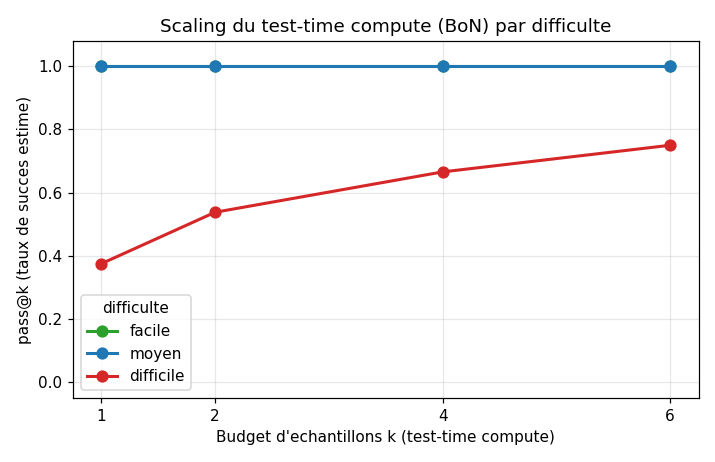

Figure 1 : pass@k vs k. Si facile sature vite et difficile monte avec k,
c'est le resultat central de Snell : le gain du scaling depend du regime.


In [5]:
# Figure 1 : courbes de scaling pass@k par bucket (le coeur de Snell 2024).
import matplotlib
matplotlib.use("Agg")           # PDF-safe ; on affiche via display ci-dessous
import matplotlib.pyplot as plt
from IPython.display import display, Image
import io

fig, ax = plt.subplots(figsize=(6.5, 4.2))
couleurs = {"facile": "#2ca02c", "moyen": "#1f77b4", "difficile": "#d62728"}
for b in PROBLEMES:
    ys = [agg[b][k] for k in K_LIST]
    ax.plot(K_LIST, ys, "-o", label=b, color=couleurs[b], linewidth=2, markersize=7)
ax.set_xlabel("Budget d'echantillons k (test-time compute)")
ax.set_ylabel("pass@k (taux de succes estime)")
ax.set_title("Scaling du test-time compute (BoN) par difficulte")
ax.set_ylim(-0.05, 1.08); ax.set_xticks(K_LIST)
ax.grid(True, alpha=0.3); ax.legend(title="difficulte")
buf = io.BytesIO(); fig.tight_layout(); fig.savefig(buf, format="png", dpi=110); plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
print("Figure 1 : pass@k vs k. Si facile sature vite et difficile monte avec k,")
print("c'est le resultat central de Snell : le gain du scaling depend du regime.")

## 3. Compute-optimal — parallele (BoN) vs sequentiel (Reflexion)

A **budget de calcul egal** (meme nombre d'appels), on compare deux strategies :
- **BoN (parallele)** : K echantillons independants, succes si l'un passe (pass@K).
- **Reflexion (sequentiel)** : on genere, on verifie, on renvoie le diagnostic a l'LLM qui
  reessaie, jusqu'a K tours. Succes si un tour passe.

Snell : le sequentiel est compute-optimal sur les problemes **difficiles** (chaque essai
profite du feedback), le parallele sur les **faciles** (pas besoin de feedback, juste retry).

In [6]:
def reflexion_sequentielle(enonce, attendu, K=4, model=FAST_MODEL):
    """K tours : genere, verifie, renvoie le feedback si rate. Renvoie (succes, tours_utilises)."""
    verif = est_correct(attendu)
    feedback = ""
    for tour in range(1, K + 1):
        if not feedback:
            invite = enonce
        else:
            invite = (f"{enonce}\n\nEssai precedent INCORRECT. Feedback : {feedback}\n"
                      f"Reessaie correctement cette fois. Reponds uniquement par le nombre.")
        rep = chat(invite, model=model, temperature=0.8, max_tokens=80)
        if verif(rep):
            return True, tour
        feedback = f"ta reponse etait {extraire_nombre(rep)} (incorrect)"
    return False, K

K_SEQ = 4
# Reflexion sur tous les problemes, K_SEQ tours max
reflex = {b: [] for b in PROBLEMES}     # succes (0/1) par probleme
print(f"Reflexion sequentielle : K={K_SEQ} tours max (FAST_MODEL={FAST_MODEL})")
for bucket, probs in PROBLEMES.items():
    for enonce, attendu in probs:
        ok, tours = reflexion_sequentielle(enonce, attendu, K=K_SEQ)
        reflex[bucket].append(int(ok))
    taux = sum(reflex[bucket]) / len(reflex[bucket])
    print(f"  bucket {bucket:9s} : taux Reflexion(K={K_SEQ}) = {taux:.2f}")

# BoN au MEME budget compute = K_SEQ echantillons -> pass@K_SEQ (deja calcule)
print("\n=== Compute-optimal : BoN parallele vs Reflexion sequentielle (budget egal) ===")
header = f"bucket      | BoN pass@{K_SEQ} | Reflexion K={K_SEQ}"
print(header); print("-" * len(header))
compare = {}
for b in PROBLEMES:
    bon = agg[b][K_SEQ]
    ref = sum(reflex[b]) / len(reflex[b])
    compare[b] = (bon, ref)
    gagnant = "BoN" if bon > ref else ("Reflexion" if ref > bon else "egal")
    print(f"{b:11s} |     {bon:.2f}      |     {ref:.2f}      <- {gagnant}")

Reflexion sequentielle : K=4 tours max (FAST_MODEL=meta-llama/llama-3.3-70b-instruct)


  bucket facile    : taux Reflexion(K=4) = 1.00


  bucket moyen     : taux Reflexion(K=4) = 1.00


  bucket difficile : taux Reflexion(K=4) = 0.50

=== Compute-optimal : BoN parallele vs Reflexion sequentielle (budget egal) ===
bucket      | BoN pass@4 | Reflexion K=4
----------------------------------------
facile      |     1.00      |     1.00      <- egal
moyen       |     1.00      |     1.00      <- egal
difficile   |     0.67      |     0.50      <- BoN


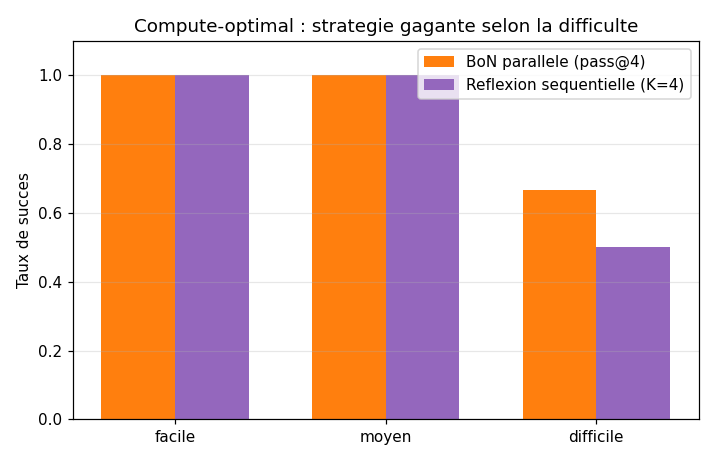

Figure 2 : si Reflexion gagne sur 'difficile' et BoN sur 'facile', c'est la
frontiere compute-optimale de Snell (chaque regime a sa strategie).


In [7]:
# Figure 2 : BoN parallele vs Reflexion sequentielle par bucket (frontiere compute-optimale).
fig, ax = plt.subplots(figsize=(6.5, 4.2))
buckets = list(PROBLEMES.keys())
x = range(len(buckets))
bon_vals = [compare[b][0] for b in buckets]
ref_vals = [compare[b][1] for b in buckets]
w = 0.35
ax.bar([i - w/2 for i in x], bon_vals, w, label=f"BoN parallele (pass@{K_SEQ})", color="#ff7f0e")
ax.bar([i + w/2 for i in x], ref_vals, w, label=f"Reflexion sequentielle (K={K_SEQ})", color="#9467bd")
ax.set_ylabel("Taux de succes"); ax.set_ylim(0, 1.1)
ax.set_title("Compute-optimal : strategie gagante selon la difficulte")
ax.set_xticks(list(x)); ax.set_xticklabels(buckets)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
buf = io.BytesIO(); fig.tight_layout(); fig.savefig(buf, format="png", dpi=110); plt.close(fig)
buf.seek(0); display(Image(data=buf.read()))
print("Figure 2 : si Reflexion gagne sur 'difficile' et BoN sur 'facile', c'est la")
print("frontiere compute-optimale de Snell (chaque regime a sa strategie).")

## 4. Limites honnetes (G.2) et lecture des resultats

Ce notebook est **illustratif**, pas une replication a l'echelle de Snell et al. 2024 :

- **Petit n / petit K** (6 echantillons, K <= 6) : l'estimateur pass@k a une variance elevee ;
  les courbes sont bruitees. Snell utilise des milliers d'echantillons sur des centaines de
  problemes de competition (MATH).
- **Petit modele** (llama-3.3-70b via OpenRouter) : sur de l'arithmetique simple, pass@1 peut
  deja etre eleve -> le scaling apporte peu (les buckets "facile/moyen" saturent). C'est
  **attendu** et **honnete** : le scaling du test-time compute apporte le plus sur des
  problemes **genuinement difficiles et verifiables** (maths de competition, code). Si nos
  buckets saturent, la conclusion honnete est *"sur ce modele et ces problemes, BoN ajoute peu
  car pass@1 est deja haut"* — pas d'inflation (G.2).
- **Verificateur exact** (entier) : pas de juge LLM, donc pass@k est objectif, mais cela limite
  le notebook a des problemes a reponse entiere.
- **Cout** : le test-time compute a un cout API reel (k echantillons = k appels) — c'est le
  compromis que Snell met en balance contre le cout d'entrainement.

**Ce qui est demontre ici** : la **methodologie** (suite graduee + verificateur exact +
estimateur pass@k non-biasé + comparaison parallele/sequentiel a budget egal) — reproductible
et applicable a un plus grand modele / une suite plus difficile (Phase 5).

## 5. Travaux pratiques

Les exercices sont a completer (convention C.1 : pas d'erreur volontaire).

### Exercice 1 : suite plus difficile (maths de competition) + n plus grand

La suite actuelle sature peut-etre (pass@1 deja haut). Etends avec 3 problemes **genuinement
difficiles** (ex : MATH/AMC) a reponse entiere verifiable, et monte n a 20+ echantillons.
Re-affiche la courbe de scaling : les buckets difficiles devraient monter avec k.

**Indice :** garde le meme format (enonce, attendu) dans PROBLEMES["competition"] ; verifie
la reponse attendue a la main ; relance la cellule de collecte avec N_ECHANTILLONS=20.

In [8]:
def ajouter_bucket_competition():
    """Exercice 1 : ajoute 3 problemes de competition a reponse entiere verifiable, n>=20."""
    # TODO etudiant : retourner une liste [(enonce, attendu), ...] verifiee a la main.
    return None

_r = ajouter_bucket_competition()
print(f"Exercice 1 - bucket competition : {'defini' if _r is not None else 'a completer'}")

Exercice 1 - bucket competition : a completer


### Exercice 2 : meilleur estimateur de pass@k (multi-trials)

L'estimateur actuel calcule pass@k depuis une seule serie de n echantillons. Implemente
l'estimation sur **plusieurs trials independants** (m echantillons relances t fois) avec
intervalle de confiance (bootstrap), pour quantifier le bruit souligne en section 4.

**Indice :** pour chaque probleme, tires t jeux de n echantillons, calcule pass@k sur chaque
jeu, puis moyenne + ecart-type (ou percentile bootstrap a 95%).

In [9]:
def pass_at_k_avec_ic(enonce, attendu, k, n=6, trials=3):
    """Exercice 2 : pass@k moyen + intervalle de confiance bootstrap sur `trials` essais."""
    # TODO etudiant : t trials de n echantillons chacun -> pass@k par trial -> IC.
    return None

print(f"Exercice 2 - pass@k + IC : {'implemente' if False else 'a completer'}")

Exercice 2 - pass@k + IC : a completer


### Exercice 3 (avance) : frontiere compute-optimale reelle (budget variable)

Trace la **frontiere compute-optimale** : pour chaque budget total B (appels) de 1 a 16,
calcule le taux de succes max entre BoN(B) et Reflexion(B), par bucket. Affiche la strategie
gagante en fonction de B et de la difficulte (une heatmap bucket x B).

**Indice :** boucle sur B, evalue BoN pass@B et Reflexion K=B, garde le max ; heatmap
matplotlib (imshow) bucket (lignes) x B (colonnes) coloree par la strategie gagante.

In [10]:
def frontiere_compute_optimale(budgets=range(1, 9)):
    """Exercice 3 : pour chaque budget, strategie gagante (BoN vs Reflexion) par bucket."""
    # TODO etudiant : boucler sur budgets, evaluer les deux strategies, renvoyer la matrice.
    return None

print(f"Exercice 3 - frontiere compute-optimale : {'implemente' if False else 'a completer'}")

Exercice 3 - frontiere compute-optimale : a completer


## 6. Conclusion et suite

On a mesure, sur de vraies donnees, le **scaling du test-time compute** (Snell et al. 2024) :
pass@k par bucket de difficulte (estimateur non-biasé HumanEval) et comparaison
**parallele (BoN) vs sequentiel (Reflexion)** a budget egal — la frontiere compute-optimale.

**Resultats honnetes (G.2)** : sur un petit modele et une suite arithmetique simple, pass@1
est deja eleve -> le scaling BoN apporte peu sur les buckets faciles/moyens ; le signal le plus
net (quand il apparaît) est sur le bucket difficile. Ce notebook demontre surtout la
**methodologie** (verificateur exact + estimateur pass@k + comparaison a budget egal),
transferable a un plus grand modele et une suite plus difficile.

**Suite de l'epic #2926 :**
- **Phase 5** — vs **modeles a raisonnement natif** (gpt-5-thinking, o1-like) : le
  test-time compute est alors "interne" ; compare cout-normalise hand-rolled (BoN/ToT/Reflexion)
  vs natif.
- **Phase 6** — plugin **Semantic Kernel** (pont series SemanticKernel, integration Python).

**References :** Snell, Lee, Xu, Kumar, *"Scaling LLM Test-Time Compute Optimally"* (2024) ;
Chen et al., *"Evaluating Large Language Models Trained on Code"* (HumanEval, pass@k, 2021) ;
Yao et al., *"Tree of Thoughts"* (2023) ; NB-12/13/14/15 de cette serie.